# &emsp;&emsp;&emsp;&emsp;&emsp;&emsp; <span style="color:red">Telecom – Churn Rate Machine Learning Project</span>

<p style="text-align:jutify;"><b>Client:</b> No-Churn Telecom<br>
<b>Category:</b> Telecom – Churn Rate ML<br>
<b>Project Ref:</b> PM-PR-0017</p>

## <span style="color:blue">1. Problem Statement</span>
### Project Goals
* Identify the key variables influencing customer churn.
* Predict customers likely to churn.
* Generate a new variable **CHURN_FLAG**:
  * **YES (1) → High churn risk**
  * **NO (0) → Low churn risk**
* Help marketing team target high-risk customers with retention offers.
* Assist customer support teams in prioritizing high-risk customers for proactive engagement and faster issue resolution.

**Machine Leaning Type:** *Supervised Machine Learning: Classification Type*

## <span style="color:blue">2.Importing Libraries</span>

In [17]:
# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
#Phi_K: powerful library for correlation analysis
#Works with categorical, ordinal, and interval (continuous) variables.
#Captures non-linear dependencies.
import phik
from phik import report

# To see all columns/rows of DataFrame, if we refresh kernel, it will reset
pd.set_option('display.max_columns', None,'display.max_rows', None)

## <span style="color:blue">3. Loading the Dataset</span>

In [18]:
#!pip install mysql-connector-python

In [19]:
# Loading dataset from MySql database
# importing mysql connector
import mysql.connector
# 1. creating the connection object
connection = mysql.connector.connect(
                                     host = "18.136.157.135",
                                     user = "dm_team3",
                                     password = "DM!$!Team!27@9!20&",
                                     database = "project_telecom"
                                     )
#2. Sql query to select all records of telecom_churn_data table
sql_query = 'select * from telecom_churn_data'

#3. reading dataset from MySql db
df = pd.read_sql(sql_query,connection)

#4. closing the connection object
connection.close()

In [20]:
df.sample(5)

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
173437,173438,Airtel,M,46,Himachal Pradesh,Bangalore,781596,2022-05-18,0,51545,7,45,1452,0
100903,100904,Reliance Jio,M,74,Punjab,Bangalore,781866,2021-05-20,0,55675,100,8,5136,1
88072,88073,Reliance Jio,M,26,Punjab,Hyderabad,195479,2021-03-16,1,72522,5,13,6140,1
224186,224187,Airtel,M,54,Bihar,Bangalore,209276,2023-01-27,1,96073,29,42,1298,0
134031,134032,Vodafone,F,39,Tripura,Delhi,304460,2021-11-01,2,116875,55,33,8081,0


In [4]:
# Creating a copy of dataset for safety purpose
telecom_churn_df = df.copy()

## <span style="color:blue">4. Basic Checks</span>

In [5]:
# Checking the dimensions
print("No. of Rows in Dataset:",telecom_churn_df.shape[0])
print("No. of Columns in Dataset:",telecom_churn_df.shape[1])

No. of Rows in Dataset: 243553
No. of Columns in Dataset: 14


In [6]:
# fetching top 5 rows of Dataset
telecom_churn_df.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [7]:
# Fetching the information about datatypes used
telecom_churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   customer_id           243553 non-null  int64 
 1   telecom_partner       243553 non-null  object
 2   gender                243553 non-null  object
 3   age                   243553 non-null  int64 
 4   state                 243553 non-null  object
 5   city                  243553 non-null  object
 6   pincode               243553 non-null  int64 
 7   date_of_registration  243553 non-null  object
 8   num_dependents        243553 non-null  int64 
 9   estimated_salary      243553 non-null  int64 
 10  calls_made            243553 non-null  int64 
 11  sms_sent              243553 non-null  int64 
 12  data_used             243553 non-null  int64 
 13  churn                 243553 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 26.0+ MB


In [8]:
# Checking statistical data of Numerical columns
telecom_churn_df.describe(exclude='O').T

,count,mean,std,min,25%,50%,75%,max
customer_id,243553.0,121777.000000,70307.839393,1.0,60889.0,121777.0,182665.0,243553.0
age,243553.0,46.077609,16.444029,18.0,32.0,46.0,60.0,74.0
pincode,243553.0,549501.270541,259808.860574,100006.0,324586.0,548112.0,774994.0,999987.0
num_dependents,243553.0,1.997500,1.414941,0.0,1.0,2.0,3.0,4.0
estimated_salary,243553.0,85021.137839,37508.963233,20000.0,52585.0,84990.0,117488.0,149999.0
calls_made,243553.0,49.010548,29.453556,-10.0,24.0,49.0,74.0,108.0
sms_sent,243553.0,23.945404,14.733575,-5.0,11.0,24.0,36.0,53.0
data_used,243553.0,4993.186025,2942.019547,-987.0,2490.0,4987.0,7493.0,10991.0
churn,243553.0,0.200478,0.400359,0.0,0.0,0.0,0.0,1.0


In [9]:
# Checking statistical data of Categorical columns
telecom_churn_df.describe(include='O').T

,count,unique,top,freq
telecom_partner,243553,4,Reliance Jio,61123
gender,243553,2,M,145977
state,243553,28,Uttarakhand,8856
city,243553,6,Chennai,40749
date_of_registration,243553,1220,2020-01-01,200


In [10]:
# Checking Missing/Null values
telecom_churn_df.isnull().sum()

customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64

In [11]:
# Checking duplicate records
telecom_churn_df.duplicated().sum()

0

#### **Key findings:** Basic checks of **telecom_churn_df** 
* **telecom_churn_data.csv:**
  * No. of rows: `243553`
  * No. of Columns: `14`
* No. of Numerical Features: `9`
* No. of Categorical Features: `5`
* **Dependent Feature:** `churn` 
* #### Identification of Datatypes present in Dataset
* As we know, after using `df.info()` there are 2 types of Datatypes: **Numerical** (like: `int64(9)`) and **Categorical** (like:`object(9)`)
* There are **No missing values** in Dataset.
* There are **No duplicate records** in Dataset.

## <span style="color:blue">5. Exploratory Data Analysis (EDA)</span>

### Important features information 
* **Column Name:---------- Description-----------------**
  * `customer_id`: Unique ID assigned to each customer
  * `telecom_partner`: Telecom service provider
  * `gender: Customer`: gender (Male/Female)
  * `age`: Age of the customer
  * `state`: State where customer resides
  * `city`: City of the customer
  * `pincode`: Residential postal code
  * `date_of_registration`: Date when customer joined telecom service
  * `num_dependents`: Number of dependents in the household
  * `estimated_salary`: Estimated annual salary of the customer
  * `calls_made`: Total number of calls made
  * `sms_sent`: Total SMS sent
  * `data_used`: Total data usage (GB)
  * `churn (Updated Name: CHURN_FLAG)`: Target variable (YES = 1, NO = 0)


#### **Checking Numerical and Categorical Features**

In [8]:
# Numerical Features
num_features=[feature for feature in telecom_churn_df.columns if telecom_churn_df[feature].dtype!='object']
print("No. of Numerical Features:",len(num_features))
print("Numerical Features:",num_features,'\n')

# Categorical Fetures
cat_features=[feature for feature in telecom_churn_df.columns if telecom_churn_df[feature].dtype=='object']
print("No. of Categorical Features:",len(cat_features))
print("Categorical Features:",cat_features)

No. of Numerical Features: 9
Numerical Features: ['customer_id', 'age', 'pincode', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used', 'churn'] 

No. of Categorical Features: 5
Categorical Features: ['telecom_partner', 'gender', 'state', 'city', 'date_of_registration']


### **Numerical Features Analysis**

In [17]:
# Numerical feature for Univariate analysis
num_features_for_analysis = ['age', 'pincode', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used', 'churn']

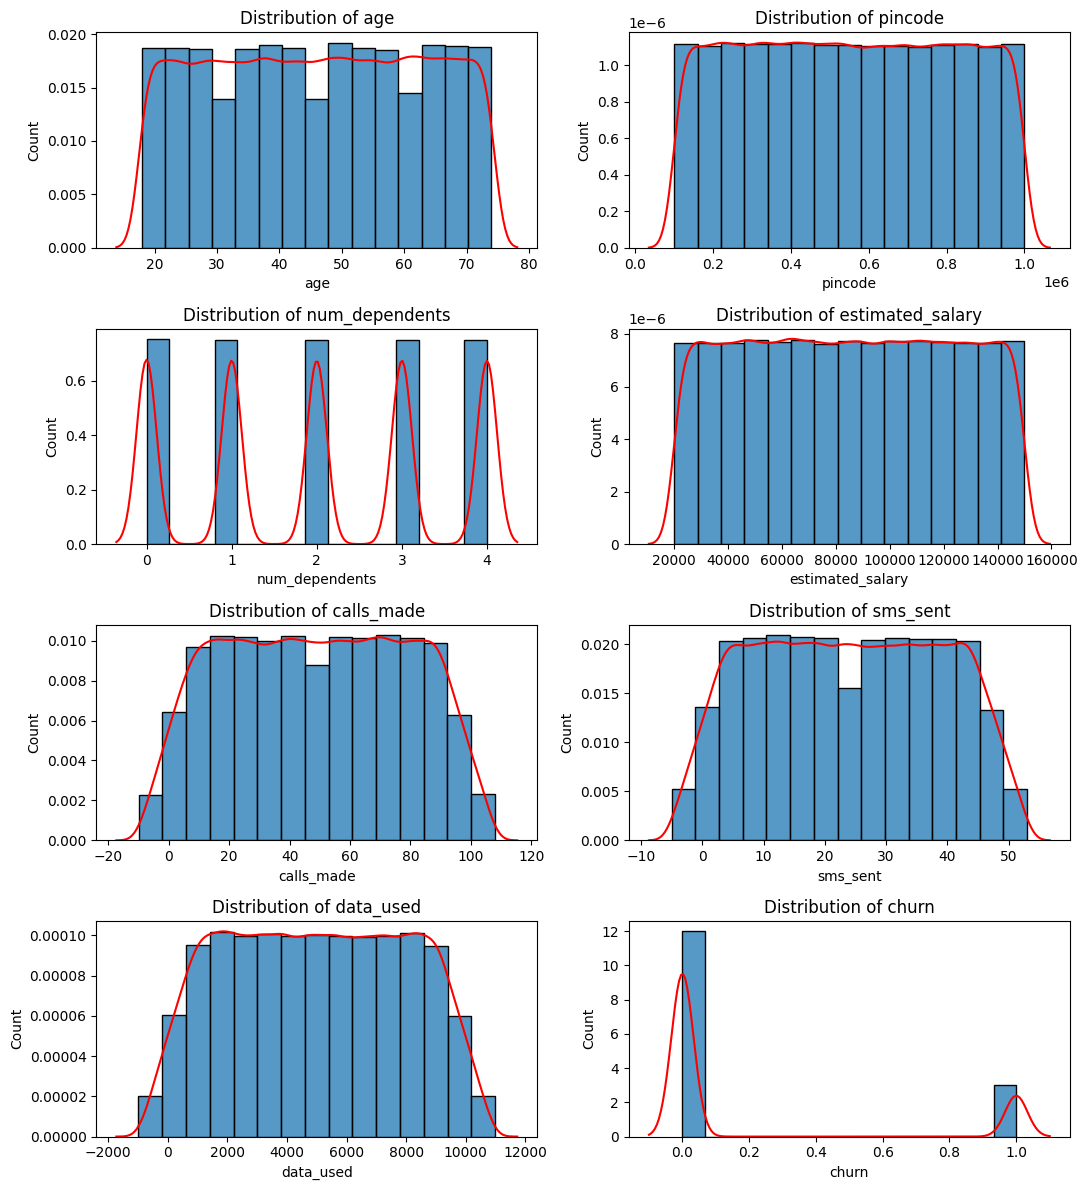

In [19]:
# Platting the Histogram with KDE of Numerical features- Univariate Analysis
plt.figure(figsize=(11,12))
plotnumber=1
for feature in num_features_for_analysis:
    plt.subplot(4,2,plotnumber)
    ax = sns.histplot(telecom_churn_df[feature],bins=15,kde=False,stat='density' )
    sns.kdeplot(telecom_churn_df[feature], color='red',ax=ax)
    plt.title(f'Distribution of {feature}',fontsize=12)
    plt.xlabel(f'{feature}')
    plt.ylabel('Count')
    plotnumber+=1
plt.tight_layout()
plt.show()

In [13]:
numerical_columns = ['age', 'pincode', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used']

In [14]:
print('Skweness of Numerical features:\n',telecom_churn_df[numerical_columns].skew())
print('=========================================================================')
print('Kurtosis of Numerical features:\n',telecom_churn_df[numerical_columns].kurt())

Skweness of Numerical features:
 age                -0.007563
pincode             0.004915
num_dependents      0.001801
estimated_salary    0.000973
calls_made         -0.002494
sms_sent            0.005314
data_used           0.003788
dtype: float64
Kurtosis of Numerical features:
 age                -1.201093
pincode            -1.200200
num_dependents     -1.301356
estimated_salary   -1.198535
calls_made         -1.113612
sms_sent           -1.116667
data_used          -1.114216
dtype: float64


#### Numerical Features Analysis
* **Skewness**
  * skewness scores of numerical features are ranging around `~0.0`.
  * It means data has absolutely `no lean`. It is `perfectly symmetrical`. There is `no long tail` of extreme high spenders or extreme heavy data users.

* **Kurtosis**
  * Numerical features have a kurtosis of roughly `~-1.2`. This is known as a `Platykurtic` distribution.
  * A kurtosis of -1.2 mathematically describes a **Uniform Distribution**.
  * It has virtually no outliers, no thin tails, and a very flat, wide peak.


* Because your data is `perfectly uniform`, you should completely **skip the Outliers removal step for these columns**.
* **No transformation** needed for these numerical features because there is no skewness to fix.

* It show that our Data is Synthetic, it means this dataset was artificially generated by a computer.

#### **Analysis of target `churn`** 

In [15]:
# Checking the Value counts of target feature
value_counts=telecom_churn_df['churn'].value_counts()
print('No of Value Counts of each category of target variable:',value_counts)

No of Value Counts of each category of target variable: churn
0    194726
1     48827
Name: count, dtype: int64


In [16]:
# Checking the % of each Value of target feature
telecom_churn_df['churn'].value_counts(normalize=True)*100

churn
0    79.952208
1    20.047792
Name: proportion, dtype: float64

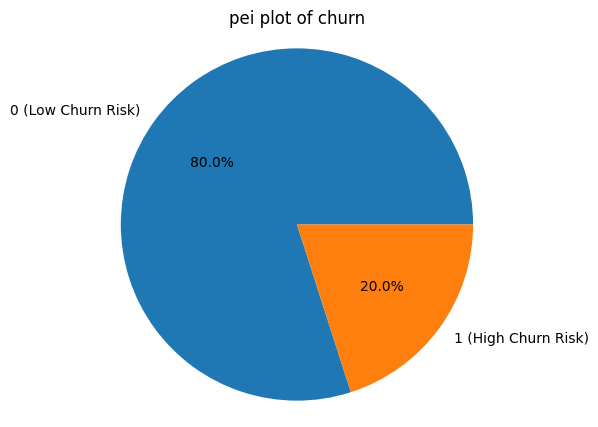

In [17]:
# Ploting the % of each value in Pie plot
plt.figure(figsize=(5,5))
plt.pie(value_counts,labels=['0 (Low Churn Risk)','1 (High Churn Risk)'],autopct='%1.1f%%')
plt.title('pei plot of churn')
plt.axis('equal')  # Ensures the pie chart is drawn as a circle
plt.show()

* As we can see in the plot, our dataset is highly imbalanced . <br>
**0:** Low Churn Risk are **~80%** <br>
**1:** High Churn Risk are **~20%**

#### **Correlation of Numerical features with target 'CHURN_FLAG' feature**

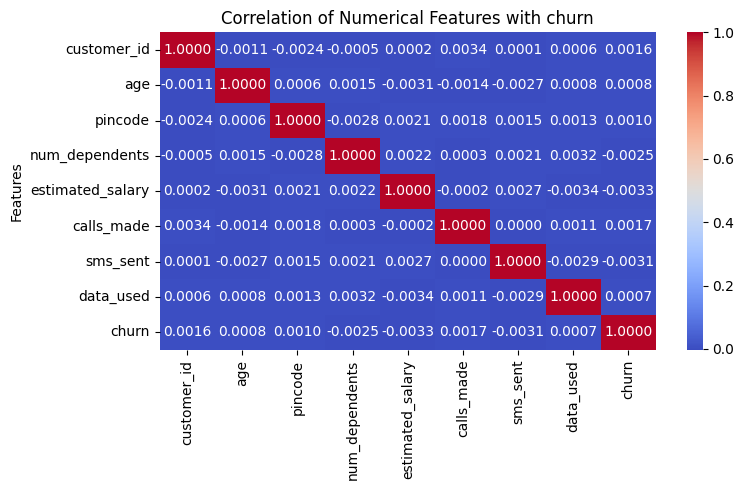


Correlation with churn:
churn               1.000000
calls_made          0.001692
customer_id         0.001649
pincode             0.001019
age                 0.000839
data_used           0.000732
num_dependents     -0.002543
sms_sent           -0.003072
estimated_salary   -0.003332
Name: churn, dtype: float64


In [25]:
# Bivariate Analysis of Numerical Feature with Target-using Heatmap
# 1. Finiding the Correlation of Numerical features
corr_matrix = telecom_churn_df[num_features].corr()

# 2.  Finding the Correlation with Target feature
target_corr=corr_matrix['churn'].sort_values(ascending=False)

# 3.  Visaulizing Heatmap for showing correlation of SalePrice with Numerical Features
plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f")
plt.title('Correlation of Numerical Features with churn')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Print the specific correlations with the target
print("\nCorrelation with churn:")
print(target_corr)

### **Outlier detection of Numerical features**

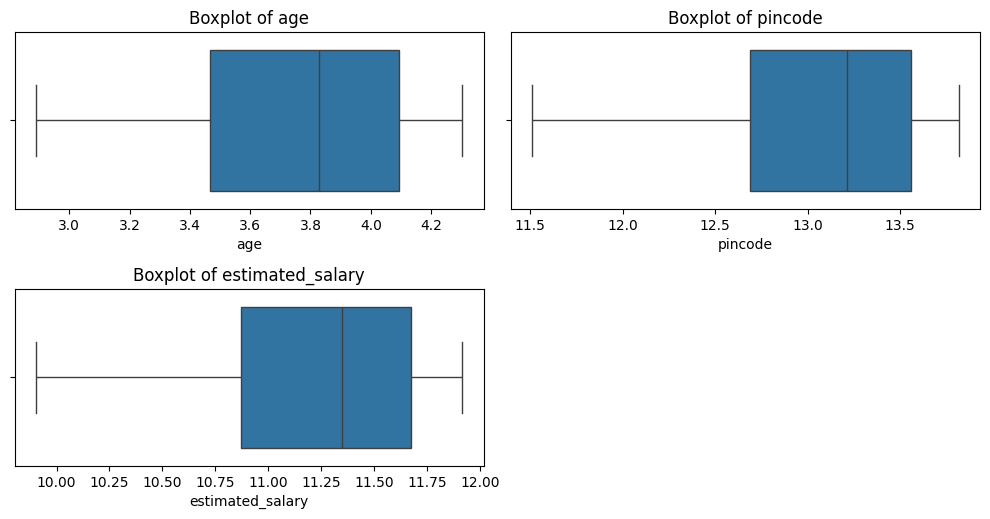

In [27]:
# Outlier Detection
plt.figure(figsize=(10,10))
plotnumber=1
for feature in num_features_for_analysis:
    data= telecom_churn_df.copy()
    if 0 in data[feature].unique():
        # This check is a safety mechanism to prevent your code from crashing with a mathematical error, log0=1.
        pass
    else:
        plt.subplot(4,2,plotnumber)
        data[feature]=np.log(data[feature])
        sns.boxplot(x=data[feature])
        plt.xlabel(feature,fontsize=10)
        plt.title(f'Boxplot of {feature}',fontsize=12)
        plotnumber+=1
plt.tight_layout()
plt.show()    

### **Categorical Feature Analysis**

In [28]:
print('No. of Categorical Features:',telecom_churn_df[cat_features].shape[1])

No. of Categorical Features: 5


In [39]:
print('Categorical Features:',cat_features)

Categorical Features: ['telecom_partner', 'gender', 'state', 'city', 'date_of_registration']


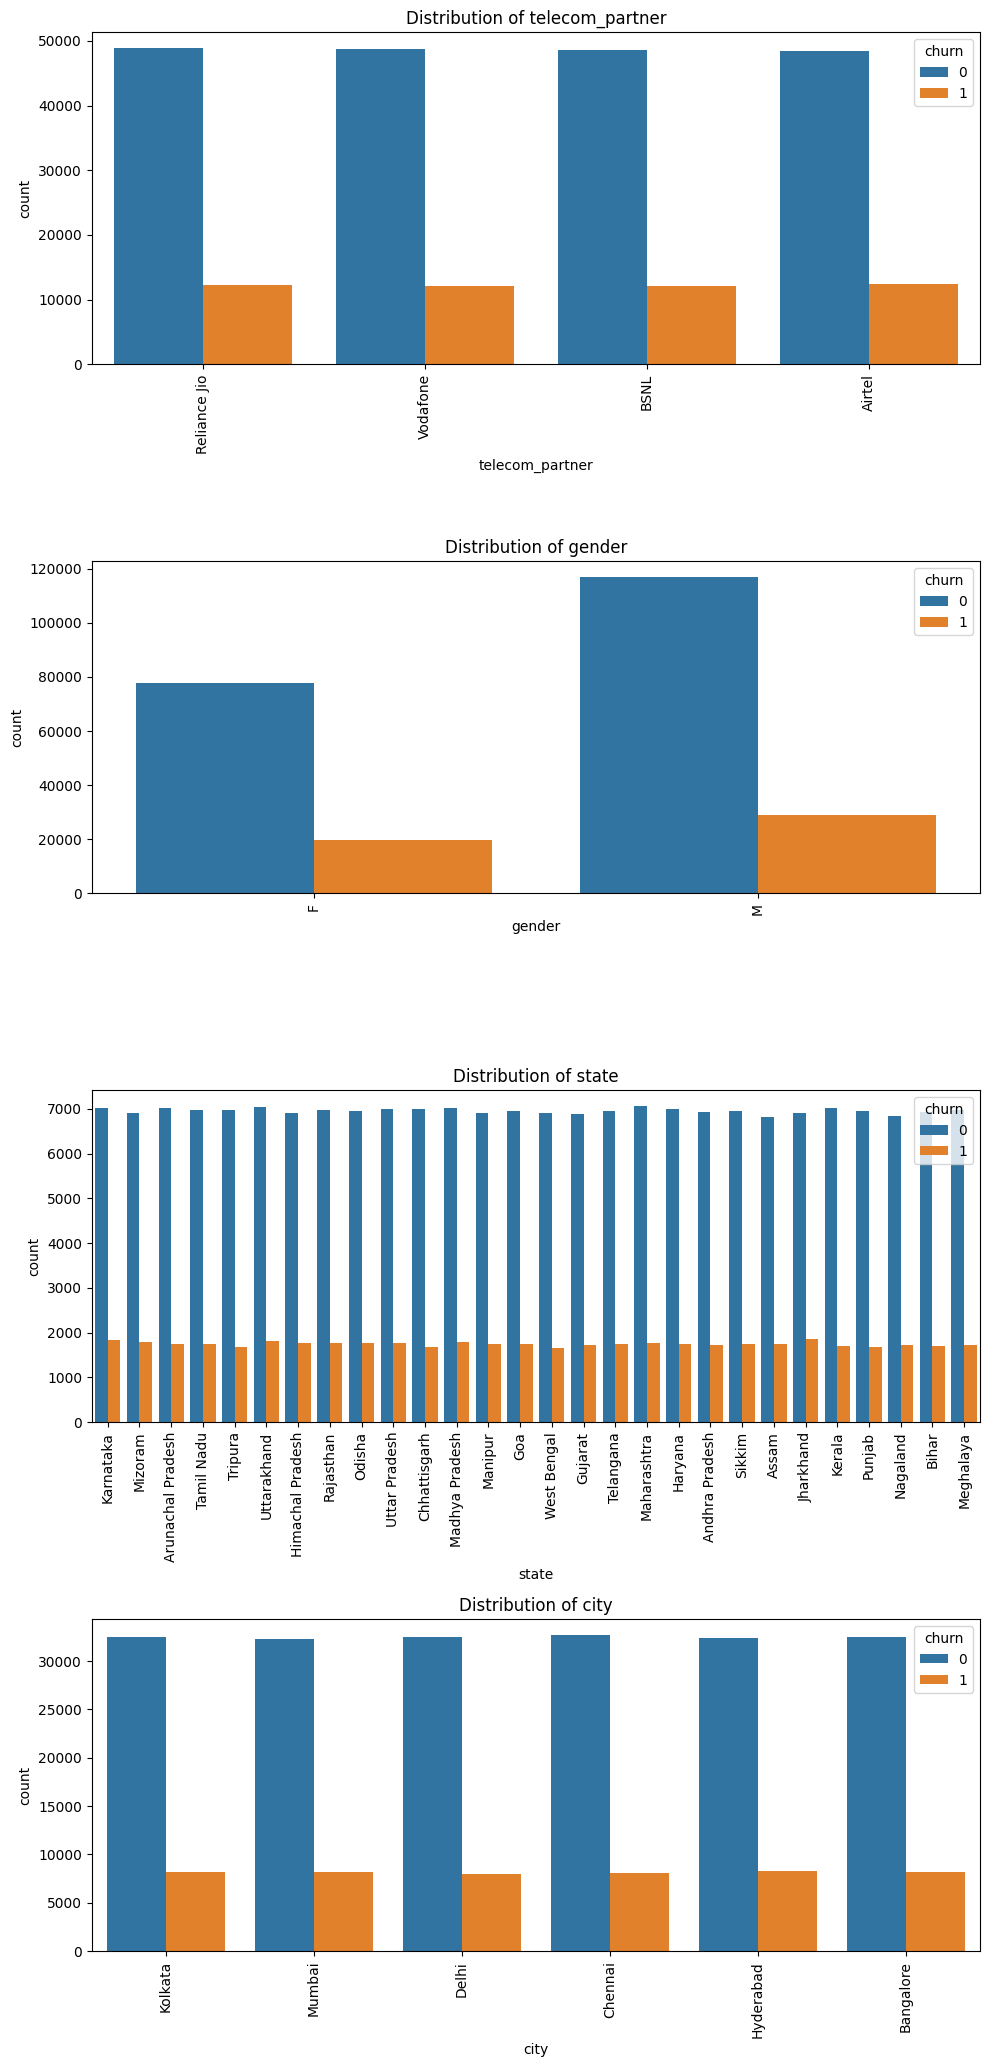

In [32]:
# ploting the categorical features counts with 'CHURN_FLAG' target
cat_features_for_analysis = ['telecom_partner', 'gender', 'state', 'city']

# Plots of categorical features
plt.figure(figsize=(10,25)) # To fix the canvas size
plotnumber=1 # initializing plot number
for feature in cat_features_for_analysis:
    plt.subplot(5,1,plotnumber) #5*1=5, means we are trying to print 5subplots 
    sns.countplot(x=telecom_churn_df[feature],hue=telecom_churn_df['churn'])
    plt.title(f'Distribution of {feature}',fontsize=12)
    plt.xlabel(feature,fontsize=10)
    plt.xticks(rotation=90)
    plt.ylabel('count',fontsize=10)
    plotnumber+=1
plt.tight_layout() # using tight layout to adjust the shape and do not overlap the figures
plt.show()

### **Correlation of Categorical features using Phi_K matrix**

interval columns not set, guessing: ['churn']


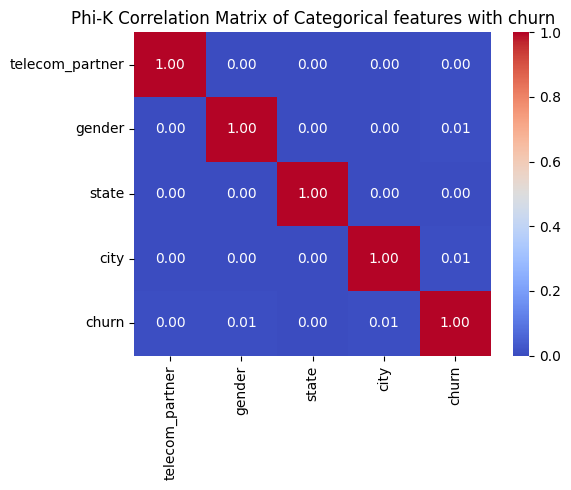


Phi-K Correlation of Categorical features with churn:
churn              1.000000
gender             0.007313
city               0.005250
telecom_partner    0.004928
state              0.000000
Name: churn, dtype: float64


In [34]:
# Correlation of Categorical Variables with  target 'churn'
# We intentionally leave out 'date_of_registration' for now, as raw dates 
# have high cardinality and can distort the matrix.
categorical_features = ['telecom_partner', 'gender', 'state', 'city']
target = 'churn'
cols_to_evaluate = categorical_features + [target]

# calculating Phi-k matrix of important Categorical features with target 'CHURN_FLAG'
phik_matrix = telecom_churn_df[cols_to_evaluate].phik_matrix()\

# visualizing Phi-k matrix
plt.figure(figsize=(6,5))
sns.heatmap(phik_matrix, annot=True, cmap="coolwarm", vmin=0, vmax=1,fmt=".2f")
plt.title("Phi-K Correlation Matrix of Categorical features with churn")
plt.tight_layout()
plt.show()

# Print the specific correlations with the target
print("\nPhi-K Correlation of Categorical features with churn:")
print(phik_matrix['churn'].sort_values(ascending=False))

### **Domain Analysis:**
#### Important features of **telecom_churn** dataset:
There are no such features who are highly affecting the target 'CHURN_FLAG', but some features are there who are affecting the Telecom Churn Prediction.
* **pincode:** It is a Residentail Postal code, who give the information about the location/area of telecom user.
* **telecom_partner:** It is Telecom service provider name.
* **age:** It is the age of the customer.
* **estimated_salary:** It is estimated annual salary of the customer.
* **data_used:** It is total data usage (GB).
* **churn:** This is target feature, which use to predict Telecom Churn.

#### Key Findings of Exploratory Data Analysis (EDA)

* **Feature Independence:** The 14 features are almost entirely uncorrelated. 
* **Distribution:** The distribution are `not` look like `Normal Distribution`, we have to perform `transformation`.
* **target:** It is highly `imbalanced` because **0** is `~80%` and **1** is `~20%`.
* **Missing Values:** There is **no missing value**,the dataset is clean and no imputation requires.
* **Features:** There are **Numerical(9)** and **Categorical(5)** features.
*  **Outliers:** This dataset have **no outliers**, we will skip Outlier detection and removal part.

## <span style="color:blue">7. Feature Engineering</span>

### Modification in Dataset

In [9]:
telecom_churn_df.sample(2)

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
60845,60846,Reliance Jio,F,50,Himachal Pradesh,Delhi,600647,2020-10-31,4,110669,36,36,3590,0
130750,130751,Vodafone,M,50,Himachal Pradesh,Chennai,222342,2021-10-16,3,114633,82,0,4570,0


* **Dropping of unused features:**
  * `customer_id` is <u>unique id</u>  of each row and `date_of_registration` is when <u>customer taken telecom service</u> so that these are the unused features during Telecom Churn Analysis, so that I am dropping these 2 features.

**changing name of target feature from `churn` to `CHURN_FLAG`**


In [10]:
# dropping the unused features
telecom_churn_df_drop = telecom_churn_df.drop(columns=['customer_id','date_of_registration'])

In [11]:
telecom_churn_df_drop.head(2)

,telecom_partner,gender,age,state,city,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,Reliance Jio,F,25,Karnataka,Kolkata,755597,4,124962,44,45,-361,0
1,Reliance Jio,F,55,Mizoram,Mumbai,125926,2,130556,62,39,5973,0


In [12]:
# Changing the name of target 'churn' to 'CHURN_FLAG'
telecom_churn_df_rename = telecom_churn_df_drop.rename(columns={'churn':'CHURN_FLAG'})

In [13]:
telecom_churn_df_rename.sample(2)

,telecom_partner,gender,age,state,city,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,CHURN_FLAG
71017,Airtel,F,36,Tripura,Mumbai,694176,1,138098,5,22,9620,0
201024,Airtel,F,19,Telangana,Chennai,603278,0,40214,22,6,2291,0


### **separating numerical and categorical features**

In [14]:
# Numerical Features
numerical_features = [feature for feature in telecom_churn_df_rename.columns if telecom_churn_df_rename[feature].dtype != 'O']
print('No. of Numerical features:',len(numerical_features))
print('Numerical features:', numerical_features)

# Categorical Features
categorical_features = [feature for feature in telecom_churn_df_rename.columns if telecom_churn_df_rename[feature].dtype == 'O']
print('No. of Categorical features:',len(categorical_features))
print('Categorical features:', categorical_features)

No. of Numerical features: 8
Numerical features: ['age', 'pincode', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used', 'CHURN_FLAG']
No. of Categorical features: 4
Categorical features: ['telecom_partner', 'gender', 'state', 'city']


### **Categorical features**

In [15]:
for feature in categorical_features:
    print('Categorical features:',telecom_churn_df_rename[feature].value_counts())
    print('===============================')

Categorical features: telecom_partner
Reliance Jio    61123
Airtel          60905
Vodafone        60802
BSNL            60723
Name: count, dtype: int64
Categorical features: gender
M    145977
F     97576
Name: count, dtype: int64
Categorical features: state
Uttarakhand          8856
Karnataka            8845
Maharashtra          8820
Madhya Pradesh       8817
Arunachal Pradesh    8757
Jharkhand            8755
Rajasthan            8750
Uttar Pradesh        8742
Haryana              8740
Kerala               8725
Tamil Nadu           8718
Odisha               8712
Goa                  8694
Telangana            8689
Sikkim               8689
Mizoram              8689
Meghalaya            8684
Himachal Pradesh     8682
Chhattisgarh         8677
Tripura              8660
Manipur              8651
Andhra Pradesh       8649
Bihar                8633
Punjab               8628
Gujarat              8610
West Bengal          8572
Nagaland             8562
Assam                8547
Name: count, 

In [14]:
# Categorical Variable separation
# Binary Categorical Variables
binary_cat_variables=[feature for feature in  telecom_churn_df_rename.columns if telecom_churn_df_rename[feature].dtype=='O' and telecom_churn_df_rename[feature].nunique()==2]
print("Binary Categorical Variables:",binary_cat_variables)

for feature in binary_cat_variables:
    print('Values of {}: {}'.format(feature, telecom_churn_df_rename[feature].unique()))


Binary Categorical Variables: ['gender']
Values of gender: ['F' 'M']


In [15]:
# Nominal Categorical Variables
nominal_cat_variables=[feature for feature in  telecom_churn_df_rename.columns if telecom_churn_df_rename[feature].dtype=='O' and telecom_churn_df_rename[feature].nunique()!=2]
print("Nominal Categorical Variables:",nominal_cat_variables,'\n')

for feature in nominal_cat_variables:
    print('Values of {}: {}'.format(feature, telecom_churn_df_rename[feature].unique()))
    print("==================================================================")

Nominal Categorical Variables: ['telecom_partner', 'state', 'city'] 

Values of telecom_partner: ['Reliance Jio' 'Vodafone' 'BSNL' 'Airtel']
Values of state: ['Karnataka' 'Mizoram' 'Arunachal Pradesh' 'Tamil Nadu' 'Tripura'
 'Uttarakhand' 'Himachal Pradesh' 'Rajasthan' 'Odisha' 'Uttar Pradesh'
 'Chhattisgarh' 'Madhya Pradesh' 'Manipur' 'Goa' 'West Bengal' 'Gujarat'
 'Telangana' 'Maharashtra' 'Haryana' 'Andhra Pradesh' 'Sikkim' 'Assam'
 'Jharkhand' 'Kerala' 'Punjab' 'Nagaland' 'Bihar' 'Meghalaya']
Values of city: ['Kolkata' 'Mumbai' 'Delhi' 'Chennai' 'Hyderabad' 'Bangalore']


#### **Encoding of categorical features**

In [16]:
# importing libraries
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,OrdinalEncoder

In [17]:
# Binary Categorical features encoding using OneHotEncoding
# Here df_filtered now stored to df_encoded
telecom_churn_df_encoded = pd.get_dummies(telecom_churn_df_rename, columns=binary_cat_variables,drop_first=True)
telecom_churn_df_encoded.sample(5)

,telecom_partner,age,state,city,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,CHURN_FLAG,gender_M
107685,BSNL,19,Arunachal Pradesh,Mumbai,183362,1,121826,32,23,407,0,False
151147,Vodafone,53,Jharkhand,Bangalore,555629,1,50326,80,49,1096,1,True
166825,Vodafone,35,Rajasthan,Kolkata,466025,2,54849,-4,26,5054,0,False
3903,Vodafone,34,Tripura,Chennai,436237,3,47342,89,22,8886,0,False
103324,Airtel,56,Uttarakhand,Bangalore,562121,0,138115,98,23,2659,0,True


In [18]:
#  Nominal Categorical features encoding using LabelEncoder
ladel_encoder = LabelEncoder()
for feature in nominal_cat_variables:
    telecom_churn_df_encoded[feature]=ladel_encoder.fit_transform(telecom_churn_df_encoded[feature])

In [19]:
telecom_churn_df_encoded.sample(5)

,telecom_partner,age,state,city,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,CHURN_FLAG,gender_M
176630,1,61,20,1,674195,4,139567,88,24,7573,0,True
150939,2,42,7,1,209526,4,141008,17,0,3090,1,True
17320,2,45,13,3,613798,2,60176,97,31,8759,0,True
22825,1,55,20,2,637678,3,95188,93,28,7323,0,True
110635,1,54,8,1,761080,4,116739,91,42,4002,1,True


## <span style="color:blue">8. Feature Selection</span>

#### **Dropping Multicollinearity from Dataset**

In [20]:
# Calculate correlation matrix and make negative correlation as positive using abs() function 
corr_matrix = telecom_churn_df_encoded.corr().abs()

# Select the upper triangle of the correlation matrix (to avoid duplicates)
# k=1 excludes the diagonal (self-correlation)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than a threshold(Eg.0.8)
to_drop = [feature for feature in upper.columns if any(upper[feature] > 0.7)]

# Drop the identified features
telecom_churn_df_dropped = telecom_churn_df_encoded.drop(columns=to_drop, axis=1)

print('df_filtered shape:',telecom_churn_df_encoded.shape)
print('df_dropped shape:',telecom_churn_df_dropped.shape)

df_filtered shape: (243553, 12)
df_dropped shape: (243553, 12)


In [21]:
telecom_churn_df_encoded.sample(2)

,telecom_partner,age,state,city,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,CHURN_FLAG,gender_M
1366,2,31,14,4,658486,1,61325,13,46,1595,0,False
57577,2,69,14,2,237212,4,135238,72,19,5805,0,True


In [22]:
telecom_churn_df_dropped.sample(2)

,telecom_partner,age,state,city,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,CHURN_FLAG,gender_M
88482,2,61,25,0,730157,0,73983,77,12,5608,0,True
101922,1,19,9,1,855908,2,109496,28,40,9736,1,False


### **Information Value (IV) Analysis**

In [23]:
#!pip install scorecardpy

**We are preventing `Data Leakage`. If we calculated IV on the entire dataset before splitting, our model would secretly learn the patterns of the test set, leading to falsely high accuracy during evaluation.**

#### **Seperating Independent & Dependent features**

In [24]:
# Seperating Dependent and Independent Features form Dataset
df_dropped = telecom_churn_df_dropped.copy()
X=df_dropped.drop('CHURN_FLAG',axis=1)
y=df_dropped['CHURN_FLAG']

#### **Train-Test Split**

In [26]:
# Train-Test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# # Printing the shape 
print('X_train:',X_train.shape)
print('X_test:',X_test.shape)
print('y_train:',y_train.shape)
print('y_test:',y_test.shape)

X_train: (194842, 11)
X_test: (48711, 11)
y_train: (194842,)
y_test: (48711,)


In [27]:
# creating a new dataframe and copying the contents to it
df_train=X_train.copy()
df_train['CHURN_FLAG']=y_train #appends y_train as the new column named binary_target

In [28]:
# #Step 1: Calculate and Filter the Training Data
import scorecardpy as sc

# # 1. Calculate the Information Value (IV) for all features of training set
print("Calculating Information Value...")
iv_summary = sc.iv(df_train, y="CHURN_FLAG")

# # 2. Display the features ranked from strongest to weakest
# # This will show us exactly what the algorithm thinks of our data
print("\n--- Information Value Ranking ---")
print(iv_summary.sort_values(by='info_value', ascending=False))

# # 3. Automatically drop useless features (IV < 0.02)
# # var_filter creates a new dataframe with only the predictive columns
print("\nFiltering out weak features...")
df_train_filtered = sc.var_filter(df_train, y="CHURN_FLAG", iv_limit=0.02)

# # 4. Separate the filtered data back into X and y for our machine learning model
X_train_selected = df_train_filtered.drop('CHURN_FLAG', axis=1)
y_train_selected = df_train_filtered['CHURN_FLAG']

print(f"\nOriginal feature count: {X_train.shape[1]}")
print(f"Selected feature count: {X_train_selected.shape[1]}")

# print('\n Interpretations')
print('IV < 0.02   : Useless for prediction')
print('0.02 - 0.1  : Weak predictor')
print('0.1 - 0.3   : Medium predictor')
print('0.3 - 0.5   : Strong predictor')
print('IV > 0.5    : Suspicious(Check for overfitting or data leakage)')

Calculating Information Value...

--- Information Value Ranking ---
            variable  info_value
3          data_used    0.357909
1   estimated_salary    0.317374
2            pincode    0.063948
5         calls_made    0.003849
4                age    0.002129
7           sms_sent    0.001844
8              state    0.000786
0               city    0.000334
9           gender_M    0.000116
6    telecom_partner    0.000079
10    num_dependents    0.000059

Filtering out weak features...
[INFO] filtering variables ...
Variable filtering on 194842 rows and 12 columns in 00:06:42 
8 variables are removed

Original feature count: 11
Selected feature count: 3
IV < 0.02   : Useless for prediction
0.02 - 0.1  : Weak predictor
0.1 - 0.3   : Medium predictor
0.3 - 0.5   : Strong predictor
IV > 0.5    : Suspicious(Check for overfitting or data leakage)


In [29]:
# # Step 2: Aligning the Test Set
# # Extract the list of columns that survived the IV filter
selected_columns = X_train_selected.columns.tolist()

# # Slice the test set to match
X_test_selected = X_test[selected_columns]

print(f"Test set aligned. New X_test shape: {X_test_selected.shape}")

Test set aligned. New X_test shape: (48711, 3)


In [30]:
# Printing the shape 
print('X_train:',X_train_selected.shape)
print('X_test:',X_test_selected.shape)
print('y_train:',y_train_selected.shape)
print('y_test:',y_test.shape)

X_train: (194842, 3)
X_test: (48711, 3)
y_train: (194842,)
y_test: (48711,)


## <span style="color:blue">9. Feature Scaling</span>

In [31]:
from sklearn.preprocessing import MinMaxScaler

# 1. Initialize the Scaler
scaler = MinMaxScaler()

# Convert all column names to strings before scaling
#X_train_selected.columns = X_train_selected.columns.astype(str)
#X_test_selected.columns = X_test_selected.columns.astype(str)
X_train_selected.columns = [str(col) for col in X_train_selected.columns]
X_test_selected.columns = [str(col) for col in X_test_selected.columns]
# 2. Fit and Transform the TRAINING data
# The scaler learns the Min and Max from X_train ONLY
X_train_scaled = scaler.fit_transform(X_train_selected)

# 3. Transform the TEST data
# The scaler applies the exact same math rules it learned from the training set
X_test_scaled = scaler.transform(X_test_selected)

# 4. Convert back to Pandas DataFrames
# Now using the string column names
x_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_selected.columns, index=X_train_selected.index)
x_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_selected.columns, index=X_test_selected.index)

print("Scaling complete. Data ranges from 0 to 1.")

Scaling complete. Data ranges from 0 to 1.


In [32]:
# Printing the shape 
print('X_train:',x_train_scaled.shape)
print('X_test:',x_test_scaled.shape)
print('y_train:',y_train_selected.shape)
print('y_test:',y_test.shape)

X_train: (194842, 3)
X_test: (48711, 3)
y_train: (194842,)
y_test: (48711,)


## <span style="color:blue">10. Model Training and Evaluation</span>

In [33]:
# Importing libraries needed for Model training and evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score)
from sklearn.metrics import ConfusionMatrixDisplay

In [34]:
# Calculate the imbalance ratio
# Format: Number of Negative Class / Number of Positive Class
neg_count = (y_train_selected == 0).sum()
pos_count = (y_train_selected == 1).sum()
ratio = neg_count / pos_count

print(f"Calculated Ratio: {ratio:.1f}")

Calculated Ratio: 4.0


In [41]:
# creating function to evaluate model
def evaluate_model(true,predicted):
    confusion_matx= confusion_matrix(true,predicted)
    accuracy= accuracy_score(true,predicted)
    f1= f1_score(true,predicted, average='weighted')
    precision= precision_score(true,predicted) 
    recall= recall_score(true,predicted)
    rocauc= roc_auc_score(true,predicted)
    classfication_rep= classification_report(true,predicted)
    return confusion_matx, accuracy, f1, precision, recall, rocauc, classfication_rep 
  
  
# Model Training
models={
    'LogisticRegression':LogisticRegression(),
    'RandomForestClassifier':RandomForestClassifier(),
    'NaiveBayes':GaussianNB(),
    'XGBClassifier':XGBClassifier(
                                   n_estimators=200,
                                   learning_rate=0.02,        # Slow and steady
                                   max_depth=4,               # Shallow trees avoid memorization
                                   min_child_weight=10,       # Requires more evidence for a rule
                                   gamma=0.5,                 # Minimum gain to make a split
                                   subsample=0.8,             # Randomly sample rows
                                   colsample_bytree=0.7,      # Randomly sample features
                                   reg_lambda=10,             # Strong L2 regularization
                                   scale_pos_weight=ratio,    # MUST include this for your imbalance!
                                   random_state=42,
                                   use_label_encoder=False,
                                   eval_metric='auc'
                                ),
	'LightGBM': LGBMClassifier(
                                # --- Control Overfitting ---
                                n_estimators=200,        
                                learning_rate=0.02,       
                                num_leaves=15,            # FIXED: Must be < 16 since max_depth is 4
                                max_depth=4,              
                                min_child_samples=20,    
                                reg_alpha=0.1,            
                                reg_lambda=0.1,           
                                colsample_bytree=0.8,     
                                subsample=0.8,            
                                subsample_freq=1,         # FIXED: Required to make 'subsample' actually work
                                                        
                                # --- Fix Class Imbalance ---
                                class_weight={0: 1, 1: 4},  
                                                        
                                # --- Speed ---
                                n_jobs=-1,
                                random_state=42
                            )
}

LogisticRegression :
Model performance for Training set
- Confusion Matrix:


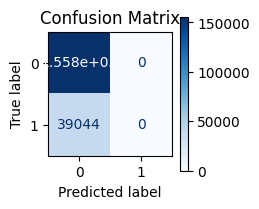

- Accuracy: 0.7996
- F1-Score: 0.7106
- Precision : 0.0000
- Recall : 0.0000
- ROCAUC : 0.5000
- Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89    155798
           1       0.00      0.00      0.00     39044

    accuracy                           0.80    194842
   macro avg       0.40      0.50      0.44    194842
weighted avg       0.64      0.80      0.71    194842

------------------------------------------------
Model performance for Test set
- Confusion Matrix:


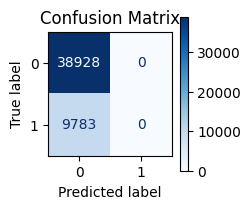

- Accuracy: 0.7992
- F1-Score: 0.7100
- Precision : 0.0000
- Recall : 0.0000
- ROCAUC : 0.5000
- Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     38928
           1       0.00      0.00      0.00      9783

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64      0.80      0.71     48711

RandomForestClassifier :
Model performance for Training set
- Confusion Matrix:


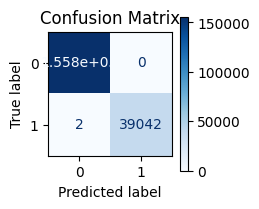

- Accuracy: 1.0000
- F1-Score: 1.0000
- Precision : 1.0000
- Recall : 0.9999
- ROCAUC : 1.0000
- Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    155798
           1       1.00      1.00      1.00     39044

    accuracy                           1.00    194842
   macro avg       1.00      1.00      1.00    194842
weighted avg       1.00      1.00      1.00    194842

------------------------------------------------
Model performance for Test set
- Confusion Matrix:


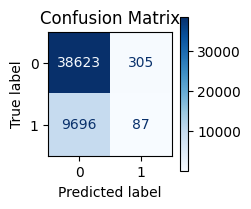

- Accuracy: 0.7947
- F1-Score: 0.7110
- Precision : 0.2219
- Recall : 0.0089
- ROCAUC : 0.5005
- Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.99      0.89     38928
           1       0.22      0.01      0.02      9783

    accuracy                           0.79     48711
   macro avg       0.51      0.50      0.45     48711
weighted avg       0.68      0.79      0.71     48711

NaiveBayes :
Model performance for Training set
- Confusion Matrix:


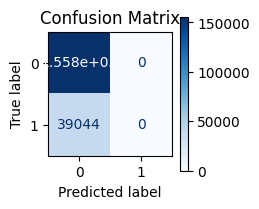

- Accuracy: 0.7996
- F1-Score: 0.7106
- Precision : 0.0000
- Recall : 0.0000
- ROCAUC : 0.5000
- Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89    155798
           1       0.00      0.00      0.00     39044

    accuracy                           0.80    194842
   macro avg       0.40      0.50      0.44    194842
weighted avg       0.64      0.80      0.71    194842

------------------------------------------------
Model performance for Test set
- Confusion Matrix:


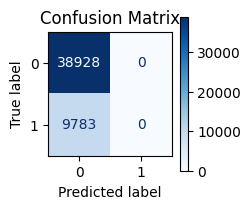

- Accuracy: 0.7992
- F1-Score: 0.7100
- Precision : 0.0000
- Recall : 0.0000
- ROCAUC : 0.5000
- Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     38928
           1       0.00      0.00      0.00      9783

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64      0.80      0.71     48711

XGBClassifier :
Model performance for Training set
- Confusion Matrix:


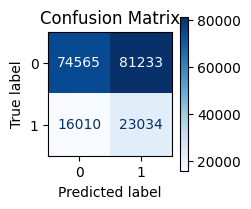

- Accuracy: 0.5009
- F1-Score: 0.5484
- Precision : 0.2209
- Recall : 0.5899
- ROCAUC : 0.5343
- Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.48      0.61    155798
           1       0.22      0.59      0.32     39044

    accuracy                           0.50    194842
   macro avg       0.52      0.53      0.46    194842
weighted avg       0.70      0.50      0.55    194842

------------------------------------------------
Model performance for Test set
- Confusion Matrix:


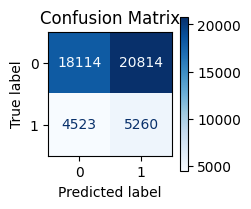

- Accuracy: 0.4799
- F1-Score: 0.5292
- Precision : 0.2017
- Recall : 0.5377
- ROCAUC : 0.5015
- Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.47      0.59     38928
           1       0.20      0.54      0.29      9783

    accuracy                           0.48     48711
   macro avg       0.50      0.50      0.44     48711
weighted avg       0.68      0.48      0.53     48711

[LightGBM] [Info] Number of positive: 39044, number of negative: 155798
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007686 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 194842, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500606 -> initscore=0.002423
[LightGBM] [Info] Start training from score 0.002423
[LightGBM] [Warning] No further splits with positive gain, be

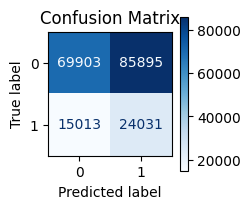

- Accuracy: 0.4821
- F1-Score: 0.5291
- Precision : 0.2186
- Recall : 0.6155
- ROCAUC : 0.5321
- Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.45      0.58    155798
           1       0.22      0.62      0.32     39044

    accuracy                           0.48    194842
   macro avg       0.52      0.53      0.45    194842
weighted avg       0.70      0.48      0.53    194842

------------------------------------------------
Model performance for Test set
- Confusion Matrix:


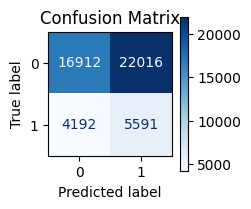

- Accuracy: 0.4620
- F1-Score: 0.5103
- Precision : 0.2025
- Recall : 0.5715
- ROCAUC : 0.5030
- Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.43      0.56     38928
           1       0.20      0.57      0.30      9783

    accuracy                           0.46     48711
   macro avg       0.50      0.50      0.43     48711
weighted avg       0.68      0.46      0.51     48711



In [42]:
# Models Training and Evaluation
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train_scaled, y_train_selected)
    # Make Predictions
    y_train_pred = model.predict(x_train_scaled)
    y_test_pred = model.predict(x_test_scaled)
    # Evaluation of Models
    confusion_matx_train, accuracy_train, f1_train, precision_train, recall_train, rocauc_train, classfication_rep_train = evaluate_model(y_train_selected, y_train_pred)
    
    confusion_matx_test, accuracy_test, f1_test, precision_test, recall_test, rocauc_test, classfication_rep_test = evaluate_model(y_test, y_test_pred)
    
    
    print(list(models.keys())[i], ':')
    print('Model performance for Training set')
    print("- Confusion Matrix:") # Removed formatting for array
    #print(confusion_matx_train)  # Print the matrix directly
    fig, ax = plt.subplots(figsize=(2, 2))
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matx_train)
    disp.plot(cmap="Blues", ax=ax, values_format=".5g")
    plt.title("Confusion Matrix")
    plt.show()
    print("- Accuracy: {:.4f}".format(accuracy_train))
    print("- F1-Score: {:.4f}".format(f1_train))
    print("- Precision : {:.4f}".format(precision_train))
    print("- Recall : {:.4f}".format(recall_train))
    print("- ROCAUC : {:.4f}".format(rocauc_train))
    print("- Classification Report:") # Removed formatting for report
    print(classfication_rep_train)  # Print the report directly
    print('------------------------------------------------')
    print('Model performance for Test set')
    print("- Confusion Matrix:") # Removed formatting for array
    #print(confusion_matx_test)  # Print the matrix directly
    fig, ax = plt.subplots(figsize=(2, 2))
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matx_test)
    disp.plot(cmap="Blues", ax=ax, values_format=".5g")
    plt.title("Confusion Matrix")
    plt.show()
    print("- Accuracy: {:.4f}".format(accuracy_test))
    print("- F1-Score: {:.4f}".format(f1_test))
    print("- Precision : {:.4f}".format(precision_test))
    print("- Recall : {:.4f}".format(recall_test))
    print("- ROCAUC : {:.4f}".format(rocauc_test))
    print("- Classification Report:") # Removed formatting for report
    print(classfication_rep_test)  # Print the report directly
    print('='*100)



### Model Comparision and Selection for Hyperparameter tuning
#### For Training Dataset
| Performance Metrics | Logistic  | Random Forest | XGBClassifier | LightGBM   | NaiveBayes |
| :-------------------| :---------| :-------------|:--------------| :----------| :----------|
| Accuracy            |  0.7996   |  1.0000       | 0.5009        |  0.4821    |  0.7996    |
| F1-Score            |  0.7106   |  1.0000       | 0.5484        |  0.5291    |  0.7106    |
| Precision           |  0.0000   |  1.0000       | 0.2209        |  0.2186    |  0.0000    |
| Recall              |  0.0000   |  0.9999       | 0.5899        |  0.6155    |  0.0000    |
| ROC-AUC Score       |  0.5000   |  1.0000       | 0.5343        |  0.5321    |  0.5000    |

#### For Test Dataset
| Performance Metrics | Logistic  | Random Forest | XGBClassifier | LightGBM   | NaiveBayes|
| :-------------------| :---------| :-------------|:--------------| :----------| :---------|
| Accuracy            |  0.7992   |  0.7947       | 0.4799        |  0.4620    |  0.7992   |
| F1-Score            |  0.7100   |  0.7110       | 0.5292        |  0.5103    |  0.7100   |
| Precision           |  0.0000   |  0.2219       | 0.2017        |  0.2025    |  0.0000   |
| Recall              |  0.0000   |  0.0089       | 0.5377        |  0.5715    |  0.0000   |
| ROC-AUC Score       |  0.5000   |  0.5005       | 0.5015        |  0.5030    |  0.5000   |

* From comparision of different Machine Learning Classification Algorithms for Training and Test dataset, `XGBClassifier` and `LightGBM` are selected to move forward.

* **Why other models not selected?**
  * **Logistic Classifier & NaiveBayes (The Baseline Failures):**
    *  It is performing `poorly` on Baseline, both the training and test sets, the Precision and Recall are exactly `0.0000`, and its **ROC-AUC** is exactly `0.5000`.
    *  it means that these models have `learned absolutely nothing`. Because the dataset is imbalanced (far more people stay than leave), these models have realized the easiest way to get `high accuracy (~79%)` is to simply predict that no one ever churns. They are completely useless for the business goals.
       
  * **RandomForest Classifier (The Overfitting trap):**
    * It scored a perfect `1.0000` across all metrics on the training set, but then crashed to `0.0000` for `Precision` and `Recall` on the test set.
    * It memorized the exact customers in our training data, but the moment it saw new people in the test set, it completely collapsed and reverted to predicting `No Churn` for everyone, just like the Logistic model.


===================================================================================================================*  
* Now We will perform **Hyperparameter Tuning** for `XGBClassifier` and `LightGBM` ML Algorithm to tune their performance.

## <span style="color:blue">11. Feature Pruning and Hyperparameter Tuning</span>

### 11.a. Feature Pruning

In [43]:
# Fetching the important features
feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': X_train_selected.columns})
print(feature_imp.sort_values(by="Value", ascending=False).iloc[:13])

   Value           Feature
1   1461           pincode
2    969         data_used
0    334  estimated_salary


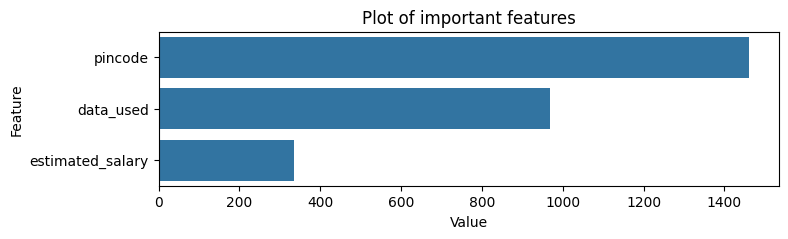

In [44]:
# Plotting the importance features 
plt.figure(figsize=(8, 2))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).iloc[:13])
plt.title('Plot of important features')
plt.show()

In [45]:
# Filtering the important features whose values are greater than 100
# Choosing Hard Threshold of 100
important_features = feature_imp[feature_imp['Value']>0]['Feature'].tolist()
# Display how many features you are keeping
print(f"Total features originally: {len(X_train_selected.columns)}")
print(f"Features with importance > 0: {len(important_features)}")
print('\nImportant features:',important_features)

Total features originally: 3
Features with importance > 0: 3

Important features: ['estimated_salary', 'pincode', 'data_used']


In [46]:
# Slice the original DataFrames to keep only those columns
x_train_final = X_train_selected[important_features]
x_test_final = X_test_selected[important_features]

print(f"Dataset cleaned! Reduced from {X_train_selected.shape[1]} to {x_train_final.shape[1]} features.")

Dataset cleaned! Reduced from 3 to 3 features.


In [47]:
# Initialize a new scaler
scaler_final = MinMaxScaler()

# Fit on training and transform both
x_train_scaled_final = scaler_final.fit_transform(x_train_final)
x_test_scaled_final = scaler_final.transform(x_test_final)

In [48]:
print('x_train_final:',x_train_scaled_final.shape)
print('x_test_final:',x_test_scaled_final.shape)
print('y_train:',y_train_selected.shape)
print('y_test:',y_test.shape)

x_train_final: (194842, 3)
x_test_final: (48711, 3)
y_train: (194842,)
y_test: (48711,)


### 11.b. Hyperparameter Tuning and Re-Training of ML Model and Evaluation

In [49]:
# Defining Parameters for Hyperparameter Tuning of different ML Classifier Algorithms
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from scipy.stats import uniform, randint
# Define the parameter grid
# XGB CLassifier
# We focus on depth, learning rate, and regularization
xgb_params = {
                'n_estimators': [50, 100, 150, 200],
                'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
                'max_depth': [3, 5, 7, 10, 15],              # Capped at 15 to prevent memorization
                'min_child_weight': [1, 5, 10, 20],
                'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],      # Fixed: Capped at 1.0
                'colsample_bytree': [0.6, 0.8, 1.0],
                'gamma': [0, 0.1, 1, 5, 10],                 # Capped at 10 to prevent paralysis
                'reg_alpha': [0, 0.1, 1, 5],
                'reg_lambda': [0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.09, 0.1]
             }
lgbm_params = {
    # Complexity Parameters (Crucial for Overfitting)
    'num_leaves': [20, 31, 50, 70],          # Keep < 50 for strong regularization
    'max_depth': [5, 8, 10, 15],             # Keep low to stop memorization
    'min_child_samples': [20, 50, 100, 200], # Higher = more conservative
    
    # Randomness (Prevent sticking to specific features)
    'subsample': [0.6, 0.8, 1.0],            # % of rows used per tree
    'colsample_bytree': [0.6, 0.8, 1.0],     # % of columns used per tree
    
    # Regularization (L1 and L2)
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0, 0.1, 0.5, 1.0],
    
    # Learning
    'learning_rate': [0.01, 0.05, 0.1]       # Lower is usually better but slower
}

In [50]:
# Models List for Hyperparameter Tuning
random_cv_models=[('XGB',XGBClassifier(
                           use_label_encoder=False, 
                           eval_metric='auc',
                           scale_pos_weight=ratio,
                           tree_method='hist' 
                          ),xgb_params),
                  ('LightGBM',LGBMClassifier(
                            n_estimators=200,           # A decent baseline number of trees
                            #class_weight='balanced',    # REQUIRED for your 0% Recall issue
                            class_weight= {0: 1, 1: 4},
                            random_state=42,
                            n_jobs=-1,
                            verbose=-1  
                             ),lgbm_params)]

In [51]:
#Configure Cross-Validation
# Must use StratifiedKFold because of the class imbalance
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [52]:
# Implementing Hyperparameter Tuning-RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
model_params={}
for name,model,params in random_cv_models:
    random_search_cv = RandomizedSearchCV(
                                          estimator=model,
                                          param_distributions=params, 
                                          n_iter=50,                # Trying 50 combinations    
                                          scoring='f1',         # Optimize for AUC, NOT Accuracy # f1
                                          cv=cv_strategy, 
                                          verbose=2,
                                          random_state=42,
                                          n_jobs=-1
                                        )
    print(f"Starting Hyperparameter Tuning for {name}:")
    random_search_cv.fit(x_train_scaled_final,y_train_selected)
    print(f"\nBest F-1 Score: {random_search_cv.best_score_:.4f}")
    print("Best Parameters:")
    print(random_search_cv.best_params_)
    print('='*50)

Starting Hyperparameter Tuning for XGB:
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best F-1 Score: 0.2984
Best Parameters:
{'subsample': 0.9, 'reg_lambda': 0.04, 'reg_alpha': 5, 'n_estimators': 150, 'min_child_weight': 20, 'max_depth': 7, 'learning_rate': 0.3, 'gamma': 10, 'colsample_bytree': 1.0}
Starting Hyperparameter Tuning for LightGBM:
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best F-1 Score: 0.3047
Best Parameters:
{'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0, 'num_leaves': 20, 'min_child_samples': 50, 'max_depth': 15, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


#### Retraining the models with Best Parameters

In [55]:
ml_models={
    'XGBClassifier':XGBClassifier(
                                   n_estimators=150,
                                   learning_rate=0.3,        # Slow and steady
                                   max_depth=7,               # Shallow trees avoid memorization
                                   min_child_weight=20,       # Requires more evidence for a rule
                                   gamma=10,                 # Minimum gain to make a split
                                   subsample=0.9,             # Randomly sample rows
                                   colsample_bytree=1.0,      # Randomly sample features
                                   reg_alpha=5,               # L1 regularization
                                   reg_lambda=0.04,             # Strong L2 regularization
                                   #min_child_samples= 200,
                                   scale_pos_weight=ratio,    # MUST include this for your imbalance!
                                   random_state=42,
                                   n_jobs=-1
                                   #use_label_encoder=False,
                                   #eval_metric='auc'
                                ),
    'LightGBM':LGBMClassifier(
                                    # --- Control Overfitting ---
                                learning_rate=0.01,       # Slower learning rate = better generalization
                                num_leaves=20,            # Keep small (e.g., < 50) to limit complexity
                                max_depth=15,              # Hard limit on tree depth
                                min_child_samples=50,    # High value prevents learning from "noise" (tiny groups)
                                reg_alpha=1,            # L1 regularization
                                reg_lambda=0.01,
                                colsample_bytree=1.0,     # Use only 80% of features per tree (adds randomness)
                                subsample=1.0,            # Use only 80% of data per tree (adds randomness)
                                
                                # --- Fix Class Imbalance (Recall = 0 problem) ---
                                #class_weight='balanced',  # Automatically weights the minority class (Defaults)
                                #class_weight= {0:1,1:5},
                                class_weight={0: 1, 1: 4},
                                # --- Speed ---
                                 n_jobs=-1,
                                 random_state=42
                                )
}

XGBClassifier :
Model performance for Training set
- Confusion Matrix:


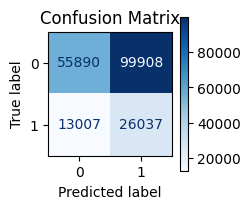

- Accuracy: 0.4205
- F1-Score: 0.4610
- Precision : 0.2067
- Recall : 0.6669
- ROCAUC : 0.5128
- Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.36      0.50    155798
           1       0.21      0.67      0.32     39044

    accuracy                           0.42    194842
   macro avg       0.51      0.51      0.41    194842
weighted avg       0.69      0.42      0.46    194842

------------------------------------------------
Model performance for Test set
- Confusion Matrix:


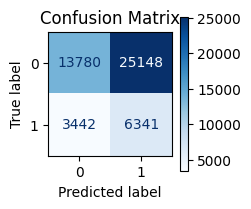

- Accuracy: 0.4131
- F1-Score: 0.4540
- Precision : 0.2014
- Recall : 0.6482
- ROCAUC : 0.5011
- Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.35      0.49     38928
           1       0.20      0.65      0.31      9783

    accuracy                           0.41     48711
   macro avg       0.50      0.50      0.40     48711
weighted avg       0.68      0.41      0.45     48711

LightGBM :
Model performance for Training set
- Confusion Matrix:


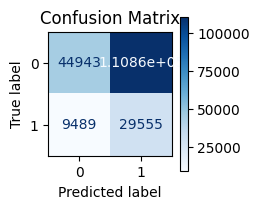

- Accuracy: 0.3824
- F1-Score: 0.4079
- Precision : 0.2105
- Recall : 0.7570
- ROCAUC : 0.5227
- Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.29      0.43    155798
           1       0.21      0.76      0.33     39044

    accuracy                           0.38    194842
   macro avg       0.52      0.52      0.38    194842
weighted avg       0.70      0.38      0.41    194842

------------------------------------------------
Model performance for Test set
- Confusion Matrix:


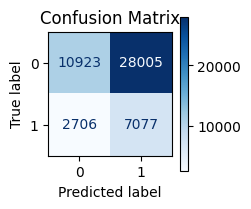

- Accuracy: 0.3695
- F1-Score: 0.3955
- Precision : 0.2017
- Recall : 0.7234
- ROCAUC : 0.5020
- Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.28      0.42     38928
           1       0.20      0.72      0.32      9783

    accuracy                           0.37     48711
   macro avg       0.50      0.50      0.37     48711
weighted avg       0.68      0.37      0.40     48711



In [56]:
# Models Training and Evaluation
for i in range(len(list(ml_models))):
    model = list(ml_models.values())[i]
    model.fit(x_train_scaled_final, y_train_selected)
    # Make Predictions
    y_train_pred = model.predict(x_train_scaled_final)
    y_test_pred = model.predict(x_test_scaled_final)
    # Evaluation of Models
    confusion_matx_train, accuracy_train, f1_train, precision_train, recall_train, rocauc_train, classfication_rep_train = evaluate_model(y_train_selected, y_train_pred)
    
    confusion_matx_test, accuracy_test, f1_test, precision_test, recall_test, rocauc_test, classfication_rep_test = evaluate_model(y_test, y_test_pred)
    
    
    print(list(ml_models.keys())[i], ':')
    print('Model performance for Training set')
    print("- Confusion Matrix:") # Removed formatting for array
    #print(confusion_matx_train)  # Print the matrix directly
    fig, ax = plt.subplots(figsize=(2, 2))
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matx_train)
    disp.plot(cmap="Blues", ax=ax, values_format=".5g")
    plt.title("Confusion Matrix")
    plt.show()
    print("- Accuracy: {:.4f}".format(accuracy_train))
    print("- F1-Score: {:.4f}".format(f1_train))
    print("- Precision : {:.4f}".format(precision_train))
    print("- Recall : {:.4f}".format(recall_train))
    print("- ROCAUC : {:.4f}".format(rocauc_train))
    print("- Classification Report:") # Removed formatting for report
    print(classfication_rep_train)  # Print the report directly
    print('------------------------------------------------')
    print('Model performance for Test set')
    print("- Confusion Matrix:") # Removed formatting for array
    #print(confusion_matx_test)  # Print the matrix directly
    fig, ax = plt.subplots(figsize=(2, 2))
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matx_test)
    disp.plot(cmap="Blues", ax=ax, values_format=".5g")
    plt.title("Confusion Matrix")
    plt.show()
    print("- Accuracy: {:.4f}".format(accuracy_test))
    print("- F1-Score: {:.4f}".format(f1_test))
    print("- Precision : {:.4f}".format(precision_test))
    print("- Recall : {:.4f}".format(recall_test))
    print("- ROCAUC : {:.4f}".format(rocauc_test))
    print("- Classification Report:") # Removed formatting for report
    print(classfication_rep_test)  # Print the report directly
    print('='*100)



#### Why I have not find threshold of both models and blend them?
* **Blending (Ensembling) won't work:**
   * Blending models only improves your score if the models have learned different real patterns. Since both your XGBoost and LightGBM models have an ROC-AUC of 0.50, they are both completely blind. Blending two blind guesses together just gives you another blind guess.
* **Thresholding will ruin your model:**
   * Lowering the threshold on random noise doesn't make the model smarter; it just lowers the model's standards. It will force the algorithm to start accusing thousands of loyal customers of churning, which will completely destroy your Precision and cost the company massive amounts of money in false alarms.

## <span style="color:blue">12. Project Conclusion & Strategic Recommendations</span>

 **Ratio**
* As we know that the ratio between `0 (Low Churn Risk)` and `1 (High Churn Risk)` is 4:1.
* ratio = neg_count / pos_count	Calculated Ratio: 4.0

#### **Challenges faced:**
* This dataset was **synthetically**, not collected from real human behavior.
* Class imbalance affecting model learning
* Trade-off between Recall and Precision 
* Limited predictive power of available features

#### **Summary:**
A robust, production-ready Machine Learning pipeline was successfully developed to predict customer churn. The architecture included rigorous data preprocessing, scaling, hyperparameter tuning (via RandomizedSearchCV), and algorithmic handling of a 4:1 class imbalance using advanced gradient boosting models (XGBoost and LightGBM). However, a comprehensive mathematical audit of the results revealed that the current dataset lacks the necessary statistical signals to predict customer churn accurately.

#### **Addressing the Project Goals**
* **Goal 1: Identify key variables influencing customer churn:**
  * `Findings:`
      * Statistical analysis (kurtosis, skewness) and model performance metrics indicate that the currently tracked metrics (e.g., age, calls_made, data_used) have zero mathematical correlation with a customer's decision to leave. These variables are not the true drivers of churn.
      * `data_used`, `estimated_salary`, `pincode` are 3 main features which are majorly affection the model predictions.
* **Goal 2: Predict customers likely to churn:**
   * `Findings:`
     * Despite extensive hyperparameter tuning and class weighting, the highest achieving models plateaued at an ROC-AUC score of ~0.50. This confirms that the current dataset does not contain the predictive patterns required to forecast churn better than baseline probability.

##### **Goal 3 & 4: Assisting Marketing and Customer Support**
* **Goal 3 & 4: Assisting Marketing and Customer Support:**
   * `Recommendation`: Do not deploy the current model into production.
     * `Justification:` Because the current data lacks a predictive signal, the model's Precision is mathematically capped at the dataset's natural baseline (~20%). If this model were used to direct marketing and support teams, 80% of the flagged "high-risk" customers would be false alarms. Offering financial retention discounts or prioritizing support for these false positives would result in massive, unnecessary financial waste for the company.

### **Strategic Next Steps**
* The machine learning architecture—including the data scaling, feature selection, and tuning pipelines—is fully operational and optimized. To achieve accurate predictions, the business must pivot its data engineering strategy.

* We recommend immediately pausing algorithmic tuning and prioritizing the collection of behavioral friction metrics, such as:

  * **1.** `Network Quality:` Frequency of dropped calls or service outages per user.

  * **2.** `Customer Frustration:` Monthly customer support ticket volume and average hold times.

  * **3.** `Financial Shock:` Sudden month-over-month billing increases or impending contract expirations.

#### **Suggestions for the Company:**
* `Collect more meaningful customer data:`
  * This dataset was **synthetically generated**, not collected from real human behavior.
  * Complaints, service quality, call drops, customer support history.
* `Implement risk-based customer segmentation:`
   * Focus retention efforts on high-risk customers.
* `Use model as an early warning system, not final decision tool.`
   * Combine with business rules or manual validation.
* `Provide personalized plans and offers:`
   * Based on usage patterns (calls, data, SMS).
* `Improve customer experience and support:`
   * Faster issue resolution
   * Better service quality
* `Launch proactive retention strategies:`
   * Loyalty rewards
   * Discounts
   * Special offers for at-risk users
* `Monitor churn across:`
   * Regions
   * Telecom partners
   * Customer segments
Regions`

# &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;Modeling Completed